In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [16]:
df = pd.read_csv('loan_data (1).csv')
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64


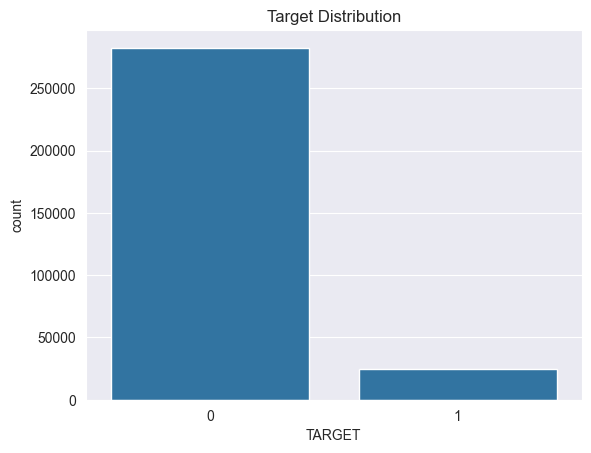

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [18]:
sns.countplot(x='TARGET', data=df)
plt.title("Target Distribution")
plt.show()

print(df['TARGET'].value_counts(normalize=True)*100)

In [19]:
X = df.drop(columns=['TARGET'])
y = df['TARGET']

In [20]:
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Numerical: 105
Categorical: 16


In [21]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

In [22]:
X_processed = preprocessor.fit_transform(X)
print("Shape after preprocessing:", X_processed.shape)

Shape after preprocessing: (307511, 245)


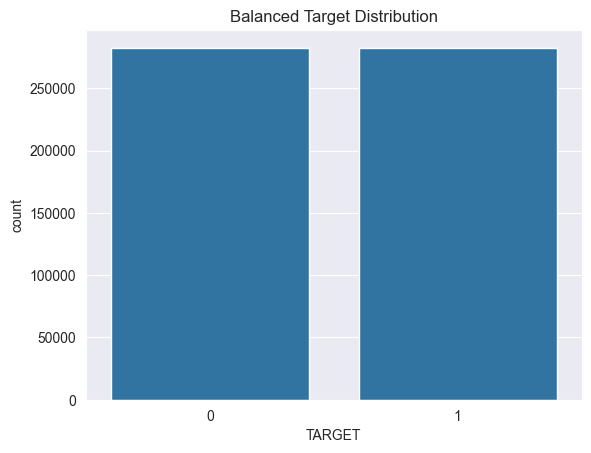

In [23]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_processed, y)

sns.countplot(x=y_res)
plt.title("Balanced Target Distribution")
plt.show()

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

In [25]:
model = Sequential([
    Dense(128, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\malha\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        31,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,809 (155.50 KB)

 Trainable params: 39,809 (155.50 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2
)

Epoch 1/10
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6836 - loss: 0.5944 - val_accuracy: 0.7560 - val_loss: 0.5056
Epoch 2/10
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7539 - loss: 0.5081 - val_accuracy: 0.8022 - val_loss: 0.4364
Epoch 3/10
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7850 - loss: 0.4607 - val_accuracy: 0.8256 - val_loss: 0.3983
Epoch 4/10
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8034 - loss: 0.4303 - val_accuracy: 0.8378 - val_loss: 0.3719
Epoch 5/10
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8164 - loss: 0.4072 - val_accuracy: 0.8461 - val_loss: 0.3544
Epoch 6/10
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8259 - loss: 0.3877 - val_accuracy: 0.8575 - val_loss: 0.3340
Epoch 7/10
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8341 - loss: 0.3732 - val_accuracy: 0.8650 - val_loss: 0.3189
Epoch 8/10
1414/1414 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8413 - loss: 0.3599 - 

In [27]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

3534/3534 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


Sensitivity (Recall): 0.8278356532658873
ROC-AUC: 0.9520790492004161


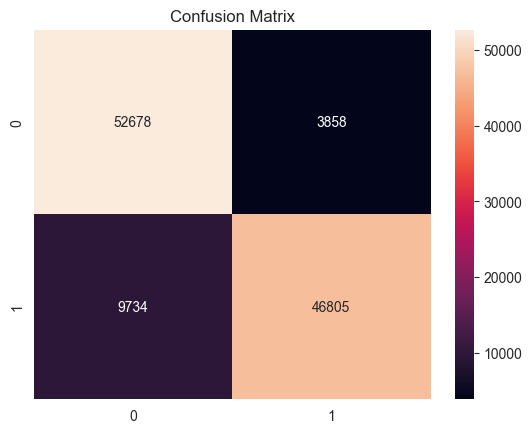

              precision    recall  f1-score   support

           0       0.84      0.93      0.89     56536
           1       0.92      0.83      0.87     56539

    accuracy                           0.88    113075
   macro avg       0.88      0.88      0.88    113075
weighted avg       0.88      0.88      0.88    113075



In [28]:
print("Sensitivity (Recall):", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))